# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
|Maria Putu Evelyne Corena Puryatma|5054251011|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)

In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.hid
data = pd.read_csv("mushrooms.csv")
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print("Shape:", data.shape)
data.info()
print("\nMissing value (NaN):", data.isnull().sum().sum())
print("Nilai '?' per kolom:")
print((data == "?").sum()[lambda s: s > 0])

Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-

In [4]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
data.nunique().sort_values()

veil-type                    1
class                        2
bruises                      2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
ring-number                  3
cap-surface                  4
veil-color                   4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
stalk-color-above-ring       9
stalk-color-below-ring       9
odor                         9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64


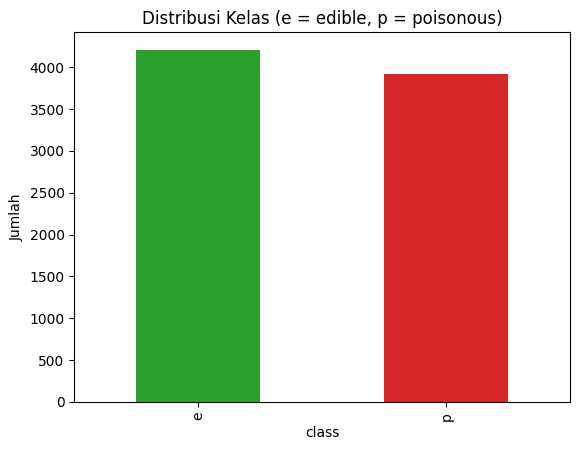

In [5]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(data["class"].value_counts(normalize=True))
data["class"].value_counts().plot(kind="bar", color=["tab:green", "tab:red"])
plt.title("Distribusi Kelas (e = edible, p = poisonous)")
plt.ylabel("Jumlah")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

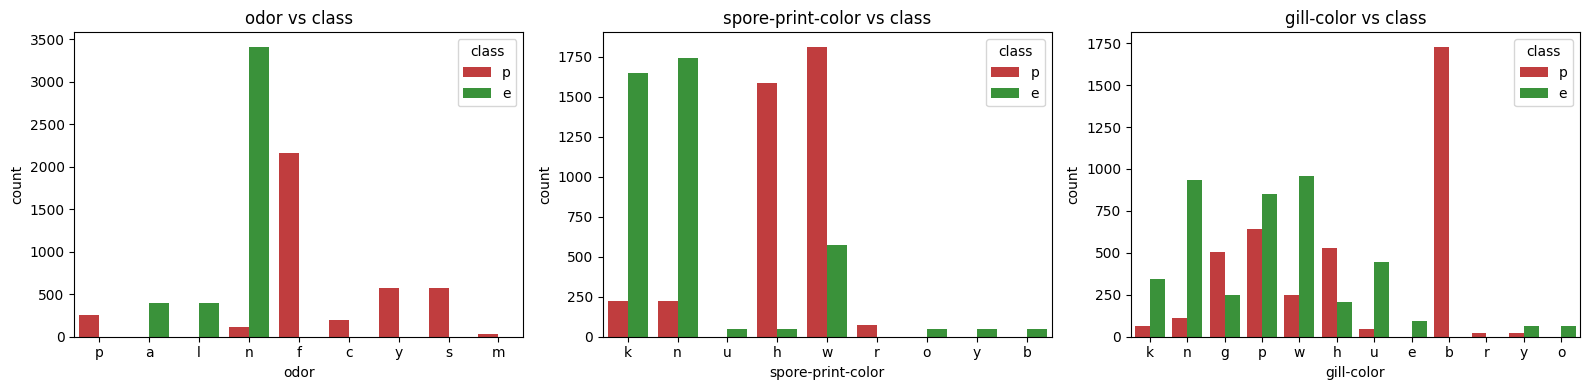

class,e,p
odor,,
a,400,0
c,0,192
f,0,2160
l,400,0
m,0,36
n,3408,120
p,0,256
s,0,576
y,0,576


In [6]:
# EDA tambahan: hubungan beberapa fitur penting dengan kelas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["odor", "spore-print-color", "gill-color"]):
    sns.countplot(data=data, x=col, hue="class", ax=ax, palette={"e": "tab:green", "p": "tab:red"})
    ax.set_title(f"{col} vs class")
plt.tight_layout()
plt.show()

# Odor hampir memisahkan kelas secara sempurna
pd.crosstab(data["odor"], data["class"])

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [7]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
# Strategi: jadikan '?' kategori tersendiri ('m' = missing), karena jumlahnya besar (~30%)
# dan informasi "tidak diketahui" itu sendiri bisa berguna untuk klasifikasi.
data["stalk-root"] = data["stalk-root"].replace("?", "m")
data["stalk-root"].value_counts()

stalk-root
b    3776
m    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [8]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
single = [c for c in data.columns if data[c].nunique() == 1]
print("Fitur dengan satu nilai unik:", single)
data = data.drop(columns=single)
data.shape

Fitur dengan satu nilai unik: ['veil-type']


(8124, 22)

In [9]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data.drop(columns="class")
y = data["class"].map({"e": 0, "p": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(6499, 21) (1625, 21)


In [10]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
ord_enc = OrdinalEncoder()
X_train_ord = ord_enc.fit_transform(X_train)
X_test_ord = ord_enc.transform(X_test)
X_train_ord[:3]

array([[ 2.,  3.,  9.,  0.,  2.,  1.,  0.,  0.,  2.,  0.,  0.,  1.,  1.,
         6.,  0.,  2.,  1.,  2.,  1.,  5.,  1.],
       [ 5.,  2.,  5.,  1.,  5.,  1.,  0.,  0.,  1.,  0.,  3.,  2.,  2.,
         2.,  7.,  2.,  2.,  0.,  7.,  1.,  6.],
       [ 0.,  2.,  3.,  0.,  5.,  1.,  1.,  0., 10.,  0.,  3.,  1.,  2.,
         7.,  7.,  2.,  2.,  4.,  7.,  3.,  1.]])

In [11]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
oh_enc = OneHotEncoder(handle_unknown="ignore")
X_train_oh = oh_enc.fit_transform(X_train)
X_test_oh = oh_enc.transform(X_test)
X_train_oh.shape

(6499, 116)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [12]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
# Nilai alpha (smoothing) dipilih dengan 5-fold cross validation pada train set.
alphas = {"alpha": [1e-3, 1e-2, 0.1, 0.5, 1.0]}
cnb = GridSearchCV(CategoricalNB(), alphas, cv=5, scoring="accuracy").fit(X_train_ord, y_train)
print("Best alpha:", cnb.best_params_, "| CV accuracy:", round(cnb.best_score_, 4))

Best alpha: {'alpha': 0.001} | CV accuracy: 0.9935


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cnb = cnb.predict(X_test_ord)
y_prob_cnb = cnb.predict_proba(X_test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [14]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bnb = GridSearchCV(BernoulliNB(), alphas, cv=5, scoring="accuracy").fit(X_train_oh, y_train)
print("Best alpha:", bnb.best_params_, "| CV accuracy:", round(bnb.best_score_, 4))

Best alpha: {'alpha': 0.001} | CV accuracy: 0.9871


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = bnb.predict(X_test_oh)
y_prob_bnb = bnb.predict_proba(X_test_oh)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [16]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
mnb = GridSearchCV(MultinomialNB(), alphas, cv=5, scoring="accuracy").fit(X_train_oh, y_train)
print("Best alpha:", mnb.best_params_, "| CV accuracy:", round(mnb.best_score_, 4))

Best alpha: {'alpha': 0.001} | CV accuracy: 0.9935


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = mnb.predict(X_test_oh)
y_prob_mnb = mnb.predict_proba(X_test_oh)[:, 1]

# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
results = {
    "Categorical NB": (y_pred_cnb, y_prob_cnb),
    "Bernoulli NB": (y_pred_bnb, y_prob_bnb),
    "Multinomial NB": (y_pred_mnb, y_prob_mnb),
}
metrics = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, prob),
    }
    for name, (pred, prob) in results.items()
}).T.round(4)
metrics

,Accuracy,Precision,Recall,F1-Score,AUC
Categorical NB,0.9908,0.9910,0.9898,0.9904,0.9996
Bernoulli NB,0.9877,0.9885,0.9860,0.9872,0.9992
Multinomial NB,0.9908,0.9910,0.9898,0.9904,0.9996


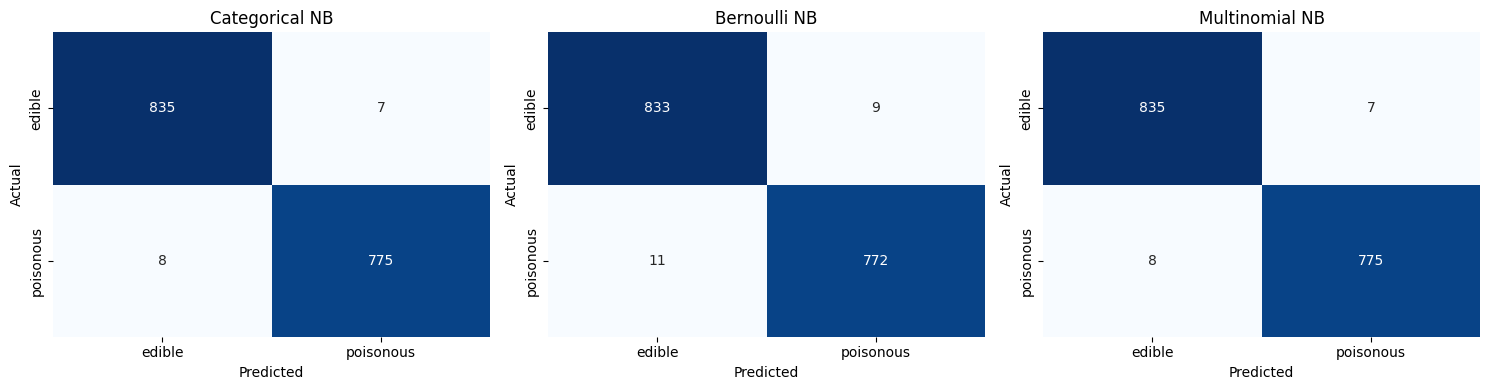

In [19]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (pred, _)) in zip(axes, results.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["edible", "poisonous"], yticklabels=["edible", "poisonous"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

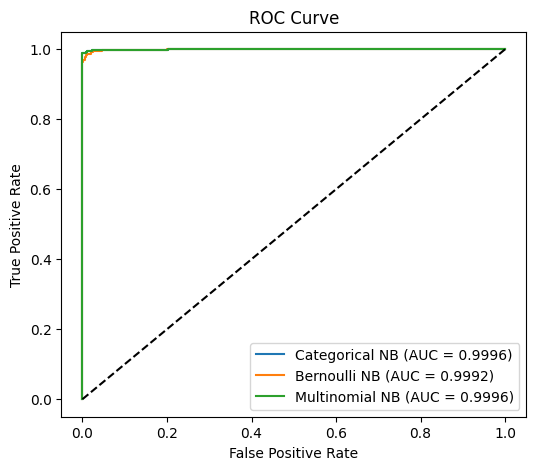

In [20]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(6, 5))
for name, (_, prob) in results.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

**Data.** Dataset berisi 8124 jamur dengan 22 fitur kategorikal dan kelas yang cukup seimbang (±52% edible, ±48% poisonous), sehingga accuracy masih layak dipakai sebagai metrik utama. Kolom stalk-root memiliki 2480 nilai '?' (±30%) yang dijadikan kategori tersendiri agar tidak kehilangan banyak data. veil-type di-drop karena hanya memiliki satu nilai. Dari EDA, fitur odor hampir memisahkan kelas secara sempurna (misalnya odor f, y, s selalu poisonous, sedangkan a dan l selalu edible).

**Hasil pada test set (1625 data), dengan alpha terbaik dari 5-fold CV (alpha = 0.001 untuk ketiga model):**

| Model | Accuracy | Precision | Recall | F1-Score | AUC | FN (beracun diprediksi aman) |
|---|---|---|---|---|---|---|
| Categorical NB | 0.9908 | 0.9910 | 0.9898 | 0.9904 | 0.9996 | 8 |
| Bernoulli NB | 0.9877 | 0.9885 | 0.9860 | 0.9872 | 0.9992 | 11 |
| Multinomial NB | 0.9908 | 0.9910 | 0.9898 | 0.9904 | 0.9996 | 8 |

**Perbandingan dan kaitannya dengan representasi data:**
 **Categorical NB** dan **Multinomial NB** menghasilkan prediksi yang identik. Hal ini masuk akal: dengan One-Hot Encoding, setiap baris memiliki tepat satu nilai 1 per fitur asli, sehingga likelihood Multinomial NB hanya menjumlahkan log-probabilitas kategori yang *muncul* — secara matematis sama dengan Categorical NB yang langsung menghitung P(fitur = kategori | kelas). Perbedaannya hanya pada cara normalisasi probabilitas, yang tidak mengubah keputusan kelas.
 **Bernoulli NB** sedikit lebih rendah. Bernoulli NB juga memperhitungkan kolom yang bernilai **0** (kategori yang *tidak* muncul) pada 116 kolom one-hot. Karena kolom-kolom one-hot dari satu fitur saling bergantung (jika satu bernilai 1, lainnya pasti 0), asumsi independensi Naive Bayes semakin dilanggar dan informasi yang sama "dihitung berulang kali", sehingga probabilitas menjadi lebih bias dan terjadi lebih banyak kesalahan (20 vs 15 salah prediksi).
 **Pengaruh smoothing (alpha).** Dengan alpha default = 1.0, accuracy hanya 0.9458 (Categorical/Multinomial) dan 0.9329 (Bernoulli), dengan 81–96 jamur beracun diprediksi aman. Pada dataset ini banyak kombinasi kategori–kelas yang benar-benar tidak pernah muncul (misalnya odor `f` tidak pernah edible). Alpha besar "mengaburkan" informasi yang sangat tegas ini, sedangkan alpha kecil (0.001) mempertahankannya sehingga accuracy naik ke ±99%.
 Nilai **AUC ≈ 0.999** untuk ketiga model menunjukkan kemampuan membedakan kelas yang sangat baik; kesalahan yang tersisa lebih karena asumsi independensi fitur daripada pemilihan threshold.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan**
Ketiga varian Naive Bayes bekerja sangat baik pada Mushroom Dataset (accuracy ≥ 98.7%, AUC ≥ 0.999). **Categorical NB** adalah pilihan paling tepat: performanya terbaik (accuracy 99.08%, F1 0.9904) dan representasinya (OrdinalEncoder) paling sesuai dengan sifat data yang seluruhnya kategorikal. Multinomial NB dengan One-Hot memberikan hasil identik, sedangkan Bernoulli NB sedikit lebih rendah karena ikut memodelkan kategori yang tidak muncul. Hyperparameter **alpha** sangat berpengaruh: menurunkan alpha dari 1.0 ke 0.001 meningkatkan accuracy sekitar 4.5–5.5 poin dan mengurangi false negative dari 81 menjadi 8.

**Saran**
Karena kesalahan paling berbahaya adalah jamur beracun diprediksi aman (false negative), threshold probabilitas dapat diturunkan agar recall kelas poisonous mendekati 100%, meskipun precision sedikit turun. Lakukan feature selection (misalnya chi-square atau mutual information) untuk mengurangi fitur yang saling berkorelasi sehingga asumsi independensi Naive Bayes lebih terpenuhi. Bandingkan dengan model yang tidak mengasumsikan independensi seperti Decision Tree / Random Forest, yang pada dataset ini biasanya mampu mencapai accuracy 100%. Gunakan stratified k-fold pada seluruh data untuk estimasi performa yang lebih stabil dibanding satu kali train-test split.